# Stock Market Analysis using Live Data (Yahoo Finance API)

Objective:
Analyze and compare the stock performance of Apple, Microsoft, Netflix,
and Google using live stock market data.
The project focuses on trend analysis, moving averages, volatility,
and correlation analysis.


#Install Required Library

In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
print("yfinance installed successfully")

yfinance installed successfully


#Importing Libraries
These libraries cover EDA + finance + visualization

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


#Defining Stock Tickers

In [5]:
tickers = ['AAPL', 'MSFT', 'NFLX', 'GOOG']


Downloading Live Stock Data (Last 3 Months)

In [6]:
data = yf.download(
    tickers,
    period="3mo",     # last 3 months
    interval="1d",    # daily data
    group_by="ticker",
    auto_adjust=True
)


[*********************100%***********************]  4 of 4 completed


“I used Yahoo Finance API via yfinance to fetch the latest 3 months of stock data.”

In [7]:
data.head()

Ticker            MSFT                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2025-09-29  510.544427  515.884407  507.929326  513.638611  17617800   
2025-09-30  512.281199  517.191991  508.707900  516.982422  19728200   
2025-10-01  513.838274  519.537629  510.734099  518.739136  22632300   
2025-10-02  516.673025  520.625589  509.726005  514.776550  21222900   
2025-10-03  516.133951  519.517632  514.037898  516.383484  15112300   

Ticker            GOOG                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2025-09-29  248.113109  251.483911  243.041421  244.200668  23157200   
2025-09-30  242.901519  243.516123  239.414795  243.391205  22541200   
2025-10-01  241.022740  246.988849  239.044035  245.379898  23967700   
2025-10-02  245.479839  247.473534  242.946489  246.269318  20657500   
2025-10-03  245.070101  246.956870  242.311906  246.289307  19941400   

Ticker            NFLX                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2025-09-29  120.500000  122.448997  118.753998  120.640999  30332000   
2025-09-30  120.640999  120.849998  117.800003  119.891998  38303000   
2025-10-01  117.549004  117.914001  116.320999  117.089996  41102000   
2025-10-02  116.150002  116.333000  113.400002  116.252998  46855000   
2025-10-03  116.500000  116.800003  114.321999  115.332001  31374000   

Ticker            AAPL                                                
Price             Open        High         Low       Close    Volume  
Date                                                                  
2025-09-29  254.313473  254.753049  252.764971  254.183594  40127700  
2025-09-30  254.613181  255.672152  252.864875  254.383408  37704300  
2025-10-01  254.793000  258.539383  254.683106  255.202606  48713900  
2025-10-02  256.331496  257.929952  253.903857  256.880981  42630200  
2025-10-03  254.423365  258.988931  253.704061  257.770111  49155600

#Converting Data to Clean Format

Yahoo gives multi-level columns, so we clean it:

In [8]:
stock_data = []

for ticker in tickers:
    df = data[ticker].reset_index()
    df['Ticker'] = ticker
    stock_data.append(df)

data = pd.concat(stock_data, ignore_index=True)
data.head()


Price,Date,Open,High,Low,Close,Volume,Ticker
0,2025-09-29,254.313473,254.753049,252.764971,254.183594,40127700,AAPL
1,2025-09-30,254.613181,255.672152,252.864875,254.383408,37704300,AAPL
2,2025-10-01,254.793000,258.539383,254.683106,255.202606,48713900,AAPL
3,2025-10-02,256.331496,257.929952,253.903857,256.880981,42630200,AAPL
4,2025-10-03,254.423365,258.988931,253.704061,257.770111,49155600,AAPL


#Basic Data Checks

In [9]:
data.info()
data.isnull().sum()
data['Ticker'].unique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    252 non-null    datetime64[ns]
 1   Open    252 non-null    float64       
 2   High    252 non-null    float64       
 3   Low     252 non-null    float64       
 4   Close   252 non-null    float64       
 5   Volume  252 non-null    int64         
 6   Ticker  252 non-null    object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 13.9+ KB


array(['AAPL', 'MSFT', 'NFLX', 'GOOG'], dtype=object)

#Converting Date Column

In [10]:
data['Date'] = pd.to_datetime(data['Date'])

#Exploratory Data Analysis (EDA)
Closing Price Distribution

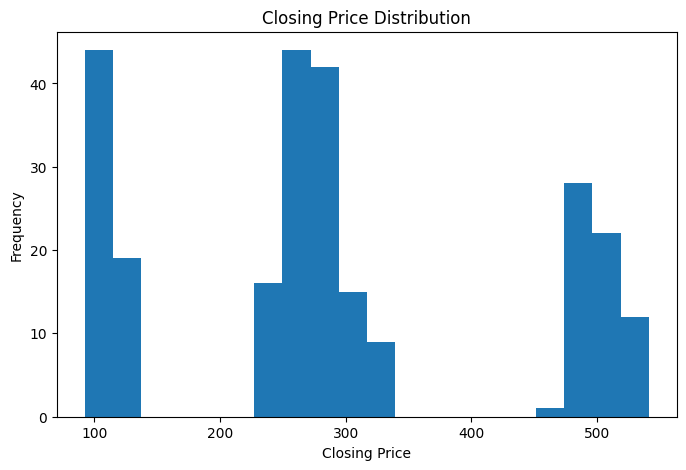

In [11]:
plt.figure(figsize=(8,5))
plt.hist(data['Close'], bins=20)
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.title("Closing Price Distribution")
plt.show()


#Volume by Company

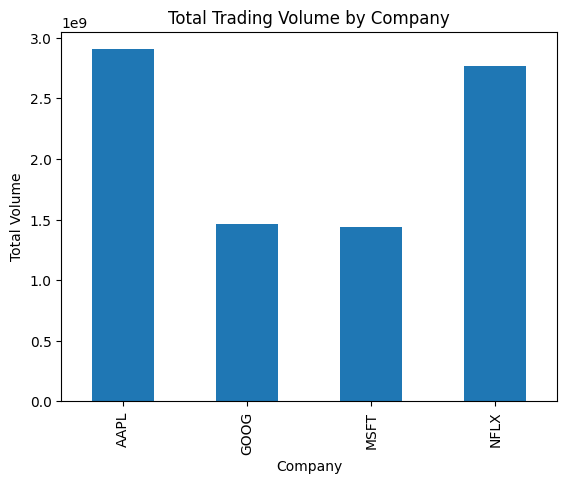

In [12]:
volume_by_ticker = data.groupby('Ticker')['Volume'].sum()

volume_by_ticker.plot(kind='bar')
plt.xlabel("Company")
plt.ylabel("Total Volume")
plt.title("Total Trading Volume by Company")
plt.show()


#Moving Average (Trend Analysis)
20-Day Moving Average

In [13]:
data = data.sort_values('Date')

data['MA_20'] = data.groupby('Ticker')['Close'].transform(
    lambda x: x.rolling(window=20).mean()
)


Plot Apple Trend

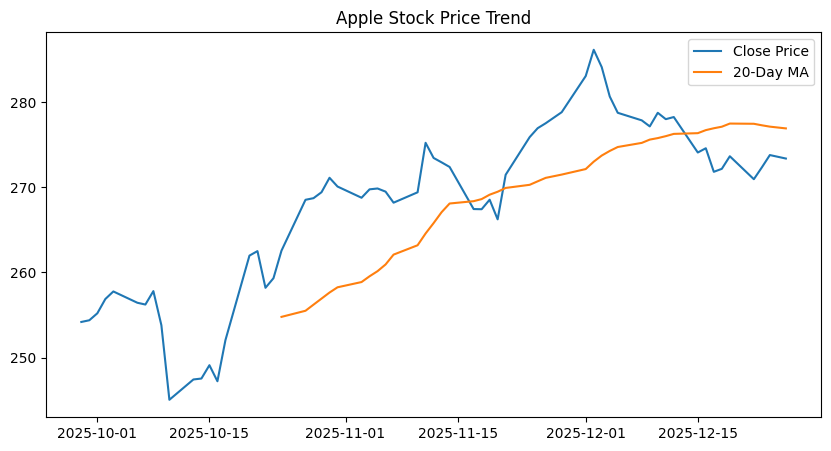

In [14]:
apple = data[data['Ticker'] == 'AAPL']

plt.figure(figsize=(10,5))
plt.plot(apple['Date'], apple['Close'], label='Close Price')
plt.plot(apple['Date'], apple['MA_20'], label='20-Day MA')
plt.legend()
plt.title("Apple Stock Price Trend")
plt.show()


“Moving averages help identify long-term trends by smoothing short-term fluctuations.”


#Volatility Analysis

In [15]:
data['Daily_Return'] = data.groupby('Ticker')['Close'].pct_change()

volatility = data.groupby('Ticker')['Daily_Return'].std()
volatility


,Daily_Return
Ticker,
AAPL,0.011101
GOOG,0.018619
MSFT,0.012032
NFLX,0.022169


#Correlation Analysis

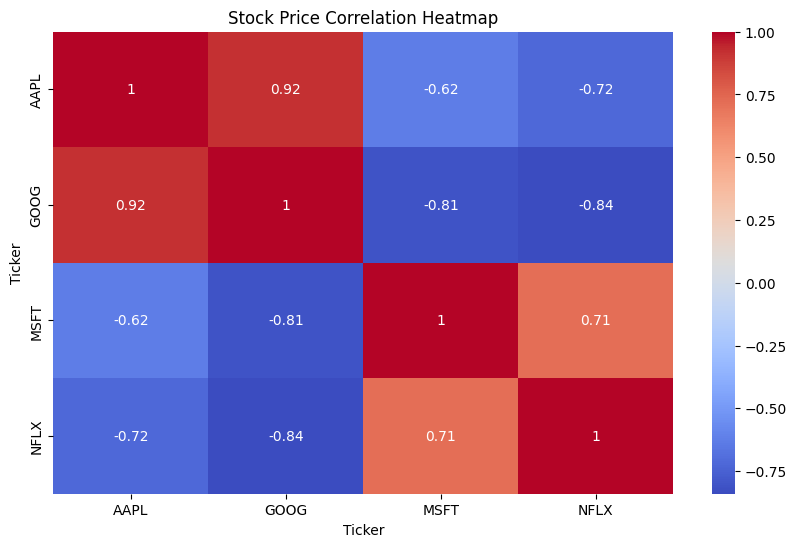

In [16]:
pivot_close = data.pivot(index='Date', columns='Ticker', values='Close')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_close.corr(), annot=True, cmap='coolwarm')
plt.title("Stock Price Correlation Heatmap")
plt.show()


#Final Conclusion

Conclusion:
- Apple and Microsoft showed relatively stable trends
- Netflix exhibited higher volatility compared to others
- Strong positive correlation exists among technology stocks
- Moving averages clearly highlighted market trends

This analysis was performed using live stock market data fetched
via Yahoo Finance API.


In [18]:
data.to_csv("stocks_live_data.csv", index=False)

